# Project

### This project explores the dataset "Hotel booking demand" by Jesse Mostipak, found on Kaggle.com. The project aims to answer the question of 'What factors influence hotel booking cancellations?', according variables found in said dataset. To answer this question, I will clean the data, explore the relationships as well as visualize the data.

## How to Run This Notebook

### Requirements
Make sure you have the following libraries installed:
pip install pandas matplotlib seaborn requests python-dotenv scikit-learn

### No API key needed, use the following data
`hotel_bookings.csv`


In [3]:
import pandas as pd

from IPython.display import display

# loading the dataset into a DataFrame
df = pd.read_csv('hotel_bookings.csv')

display(df.head())
print(df.head())

print(df.info())

display(df.head())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# Exporting raw data to repo so readers don't need an API key
df.to_csv("hotel_bookings_raw.csv", index=False)

In [5]:
# Dataset overview

# number of rows and columns

num_rows, num_columns = df.shape
print(f"Rows: {num_rows}")
print(f"Columns: {num_columns}")

#Missign values

missing_values= df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("\nMissing values:")
print(missing_values)

Rows: 119390
Columns: 32

Missing values:
children         4
country        488
agent        16340
company     112593
dtype: int64


### Cleaning the data

In [6]:
# Removing negative ADR values (Average daily rate)

df = df[df['adr'] >= 0]

# fill in missing values

df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna('Unknown')


# Convert 'agent' to string
df['agent'] = df['agent'].astype(str)

In [7]:
# confirming cancellation rate

cancellation_rate = df['is_canceled'].mean()*100
print(f"Cancellation rate: {cancellation_rate:.2f}%")

Cancellation rate: 37.04%


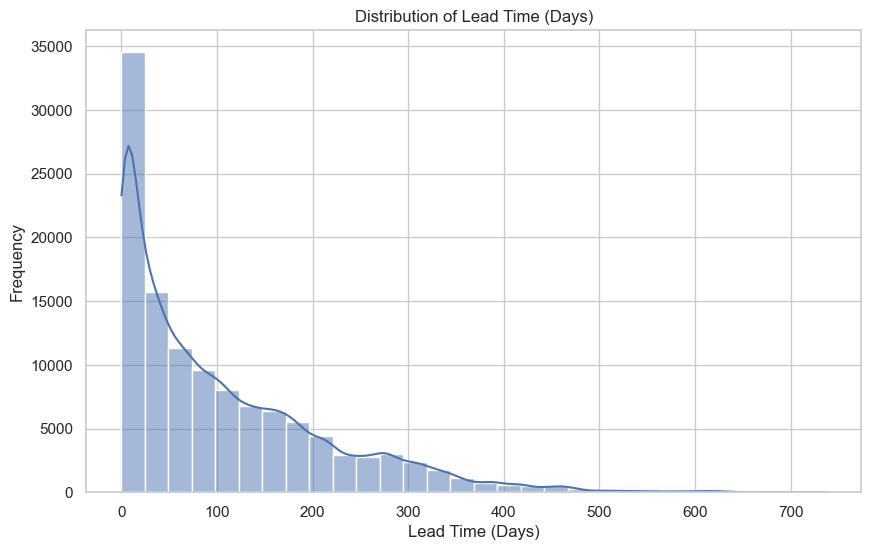

In [8]:
# understanding the distribution of lead_time, adr, previous_cancellations, etc

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(10,6))
sns.histplot(df['lead_time'], bins = 30, kde= True)
plt.title('Distribution of Lead Time (Days)')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Frequency')
plt.show()

#here I wrote the code individally for the 'lead time' as to show how I would make a histogram. In the following cell I will loop the code to get a histogram for each variable.

#### Hotel booking 'lead time' is the number of days between a guest making a reservation and their scheduled arrival date. It is a critical KPI. This histogram shows us that booking are often made close to their stay date. 

#### ^ Up here I wrote the code individally for the 'lead time' as to show how I would make a histogram. In the following cell I will loop the code to get a histogram for each variable.

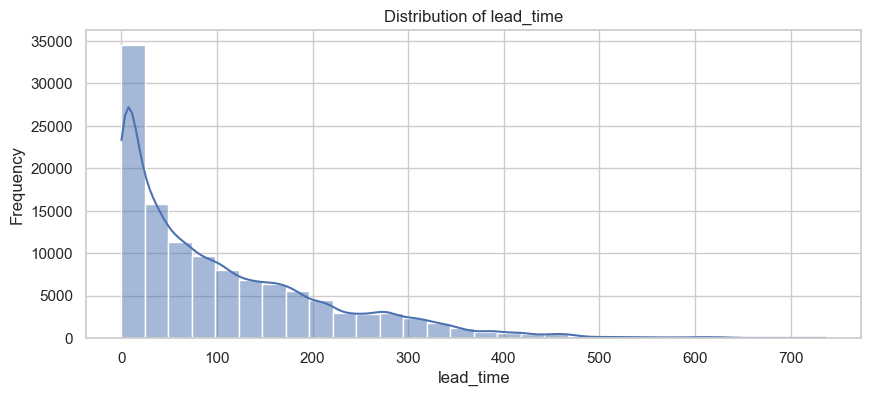

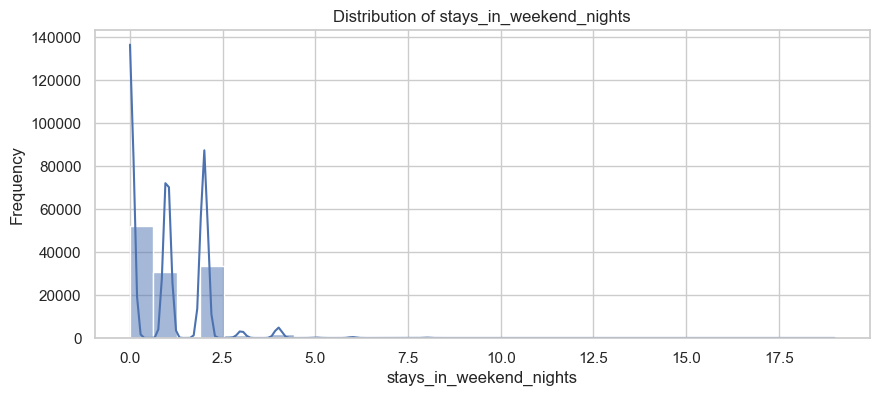

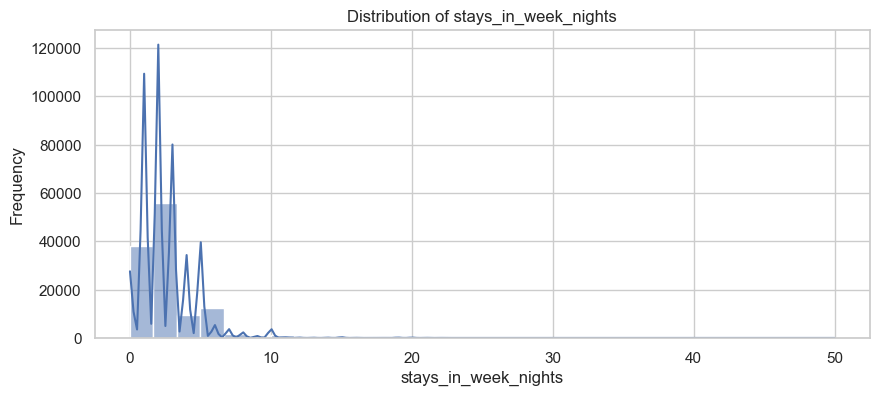

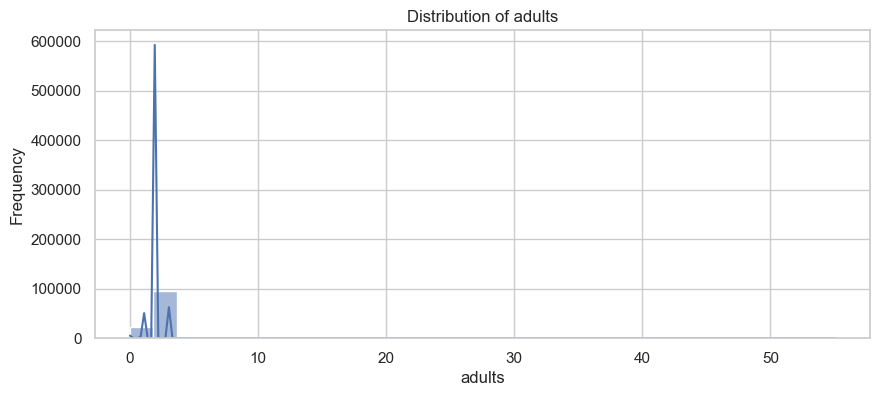

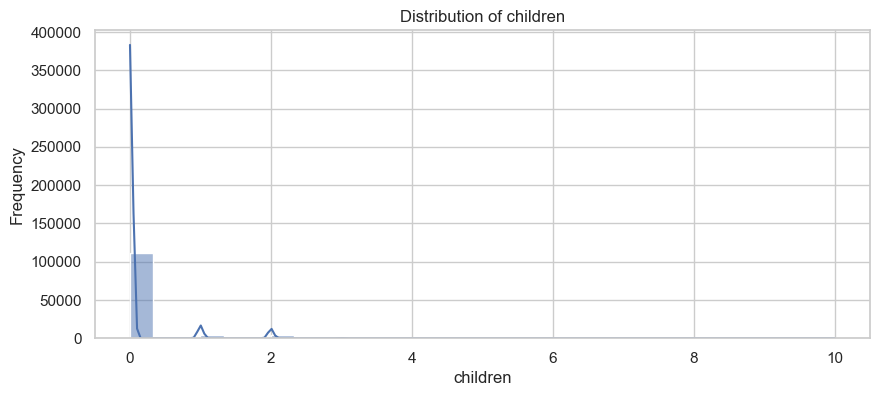

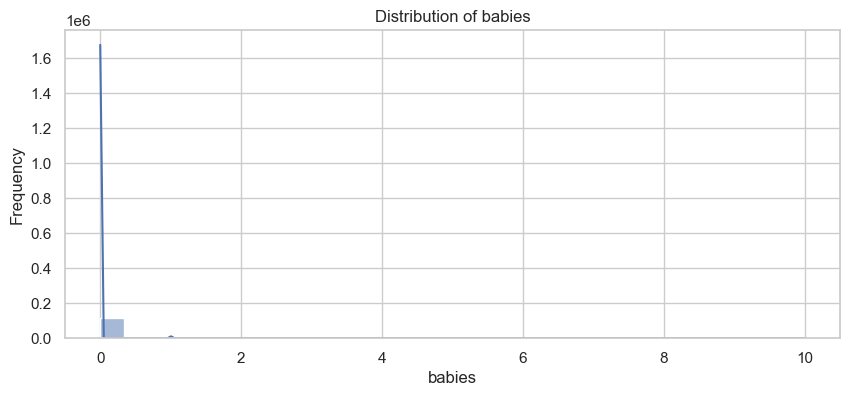

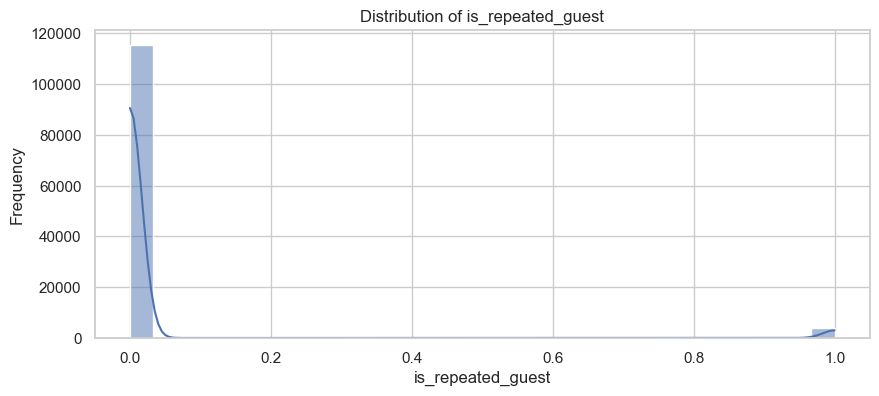

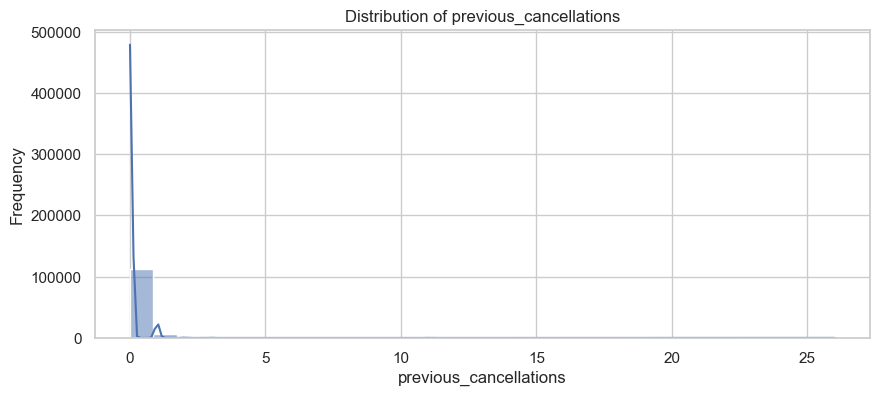

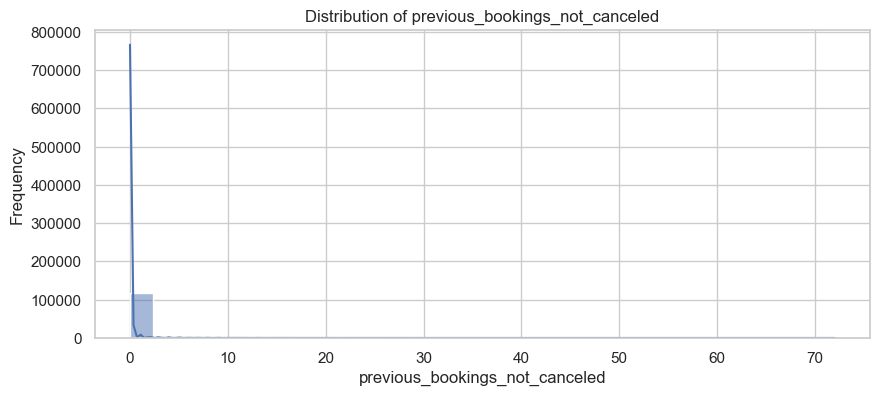

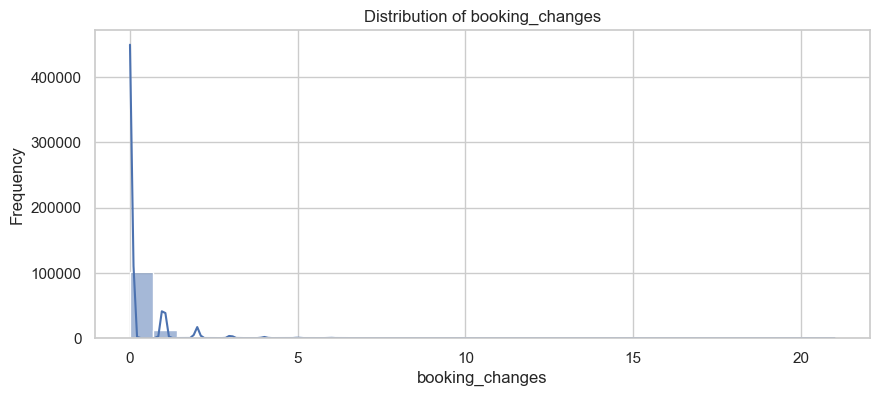

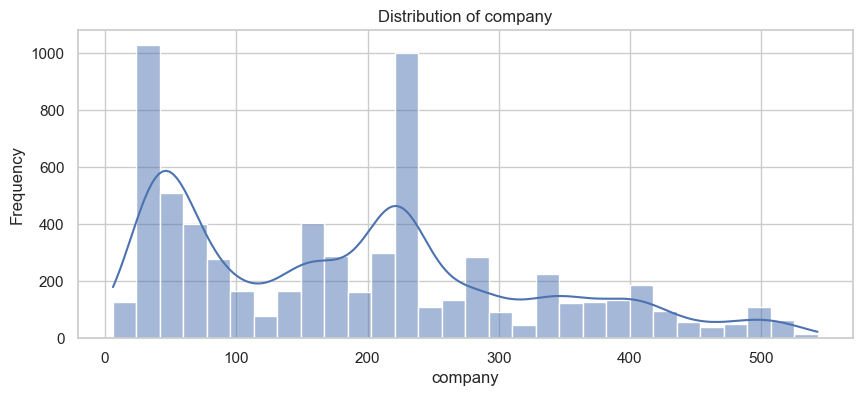

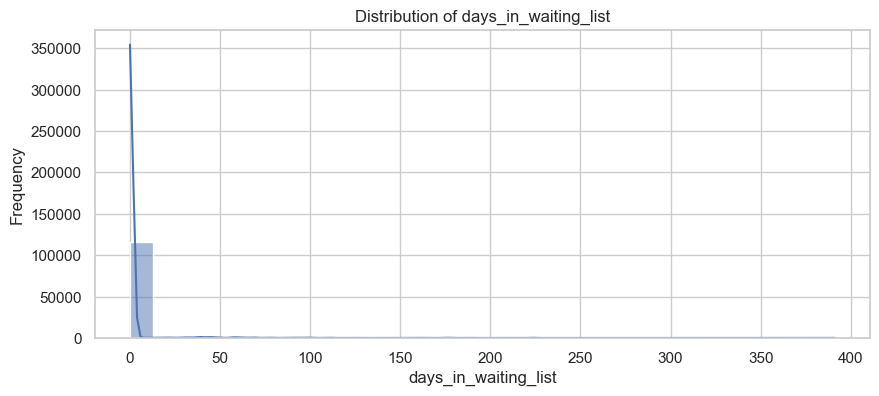

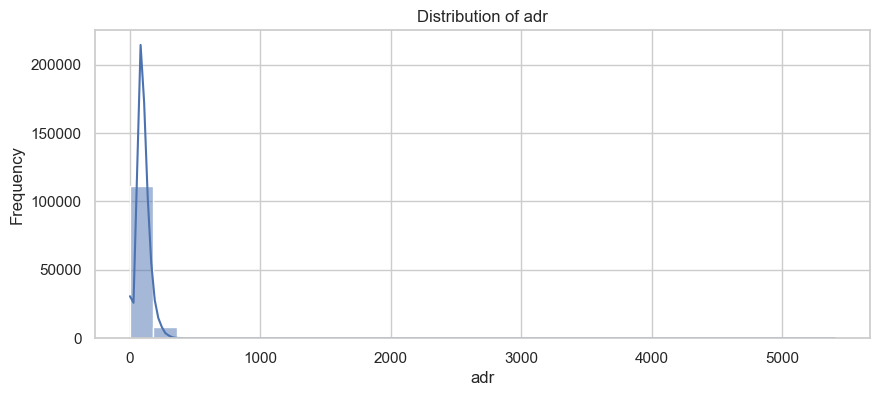

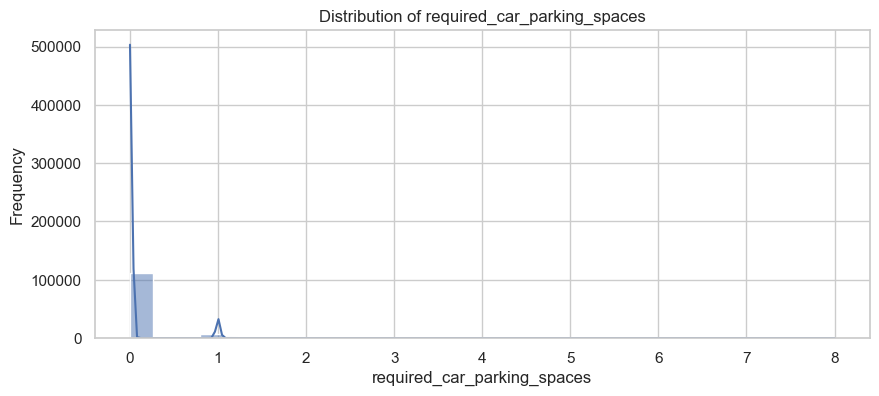

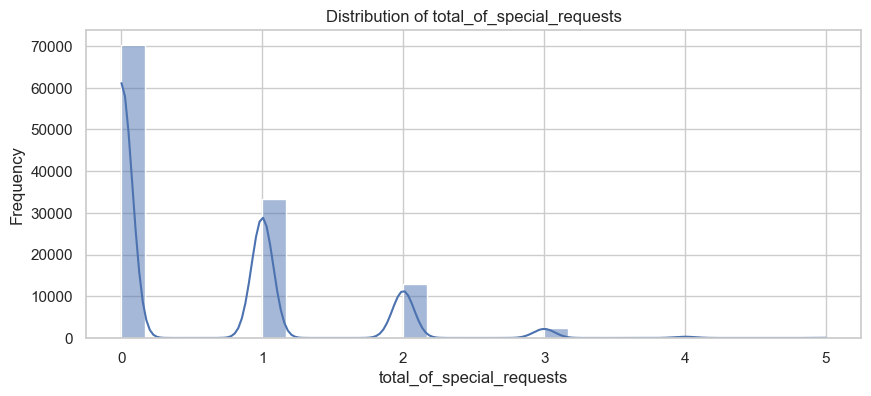

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Selecting numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = [col for col in numeric_cols if col not in ['is_canceled', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month']]

# Plotting histograms for each numeric column
for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

### Now let's see, with the help of 'lead_time', whether last minute bookings are more frequently cancelled than non-last-minute bookings. 

#### I define last-minute bookings as bookings made 0-7 days before the intended staying start.




C:\Users\loval\AppData\Local\Temp\ipykernel_3684\3769902280.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancellation_by_lead_time = df.groupby('lead_time_bin')['is_canceled'].mean() * 100


Cancellation Rate by Lead Time:
0-7 days : 9.39%
8-14 days : 20.33%
15-30 days : 30.3%
31-60 days : 36.34%
61-90 days : 39.74%
91-120 days : 44.04%
121-180 days : 44.89%
181-365 days : 55.2%
365+ days : 67.97%


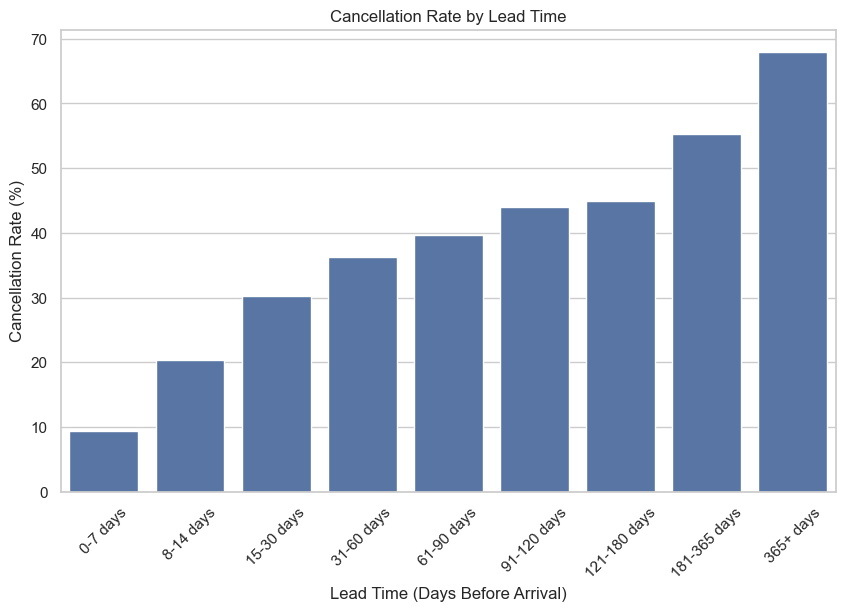

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# defining the bins
bins = [0,7,14,30,60,90,120,180,365,1000]
labels = ['0-7 days', '8-14 days', '15-30 days', '31-60 days', '61-90 days', '91-120 days', '121-180 days', '181-365 days', '365+ days']

# new column
df['lead_time_bin'] = pd.cut(df['lead_time'], bins = bins, labels = labels, right = False)


cancellation_by_lead_time = df.groupby('lead_time_bin')['is_canceled'].mean() * 100

#sort
cancellation_by_lead_time = cancellation_by_lead_time.reindex(labels)


print('Cancellation Rate by Lead Time:')
for bin_name, rate in cancellation_by_lead_time.items():
    print(f"{bin_name} : {round(rate,2)}%")


plt.figure(figsize=(10, 6))
sns.barplot(x=cancellation_by_lead_time.index, y=cancellation_by_lead_time.values)
plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time (Days Before Arrival)')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.show()



#### This tells us that cancellation rates increase steadily the further in advance the booking is made.

#### Following these finding, I want to fins out if this has to fo with deposits and price sensitivity. 

#### I will check if deposit_type correlates with lead time (e.g., are long-lead-time bookings more likely to have "No Deposit" or "Refundable" deposits). I will also ompare adr (Average Daily Rate) across lead time bins. Are earlier bookings cheaper?

In [11]:
# Grouping by lead_time_bin and deposit_type, then calculating cancellation rates
deposit_by_lead_time = df.groupby(['lead_time_bin', 'deposit_type']) ['is_canceled'].mean()*100


deposit_by_lead_time_formatted = deposit_by_lead_time.apply(
    lambda x: f"{round(x, 2)}%"
)

deposit_by_lead_time = deposit_by_lead_time.reindex(labels)

print(deposit_by_lead_time_formatted.unstack())

deposit_type  No Deposit Non Refund Refundable
lead_time_bin                                 
0-7 days           8.93%     89.62%     16.67%
8-14 days         19.68%     88.16%      4.35%
15-30 days        28.15%     96.35%      60.0%
31-60 days        32.36%      99.8%      40.0%
61-90 days         32.1%     99.72%     66.67%
91-120 days       34.59%     99.87%     100.0%
121-180 days      34.91%     98.31%     18.89%
181-365 days      39.71%     99.86%      28.0%
365+ days         20.57%     100.0%     33.33%


C:\Users\loval\AppData\Local\Temp\ipykernel_3684\495946247.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  deposit_by_lead_time = df.groupby(['lead_time_bin', 'deposit_type']) ['is_canceled'].mean()*100


In [12]:
deposit_counts = df.groupby(['lead_time_bin', 'deposit_type']).size()
print(deposit_counts.unstack())

deposit_type   No Deposit  Non Refund  Refundable
lead_time_bin                                    
0-7 days            18303         106           6
8-14 days            7293          76          23
15-30 days          11851         384           5
31-60 days          16174        1014           5
61-90 days          11288        1435           3
91-120 days          8959        1514           2
121-180 days        13359        2538          90
181-365 days        16120        5603          25
365+ days            1293        1917           3


C:\Users\loval\AppData\Local\Temp\ipykernel_3684\2393338554.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  deposit_counts = df.groupby(['lead_time_bin', 'deposit_type']).size()


#### Due to small sample sizes for Refundable and potential misclassification in Non Refund deposit types, I focused on No Deposit bookings, which had large, reliable sample sizes across all lead times.

#### Cancellation Rates Increase with Lead Time


#### 0-7 days: 8.93% cancellation rate (lowest).


#### 181-365 days: 39.71% cancellation rate (highest).

#### Guests with no deposit are less financially committed, so they’re more likely to cancel if plans change. This effect is stronger for early bookings (long lead times), where uncertainty is higher. See bar plot down below.

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=cancellation_rates.index,
    y=cancellation_rates.values,
    color = 'green'
)
plt.title("Cancellation Rates by Lead Time for No Deposit Bookings")
plt.xlabel("Lead Time Bin")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.ylim(0, 50) 
plt.tight_layout()
plt.show()




NameError: name 'cancellation_rates' is not defined

<Figure size 1000x600 with 0 Axes>

## Question: Are refundable/non-refundable bookings cheaper or more expensive?

In [ ]:
# Filter for 'No Deposit' only
no_deposit_data = df[df['deposit_type'] == 'No Deposit']

# Calculate average ADR by lead_time_bin
adr_by_lead_time = no_deposit_data.groupby('lead_time_bin')['adr'].mean()

print("Average ADR by Lead Time for No Deposit Bookings:")
print(adr_by_lead_time)


import seaborn as sns
import matplotlib.pyplot as plt

# Filter for 'No Deposit' bookings
no_deposit_data = df[df['deposit_type'] == 'No Deposit']

# Calculate average ADR by lead_time_bin
adr_by_lead_time = no_deposit_data.groupby('lead_time_bin')['adr'].mean()

# Plot bar plot
plt.figure(figsize=(7, 5))
sns.barplot(
    x=adr_by_lead_time.index,
    y=adr_by_lead_time.values,
    color="red",
)

# Add title and labels
plt.title("Average Daily Rate (ADR) by Lead Time for No Deposit Bookings", fontsize=14)
plt.xlabel("Lead Time Bin", fontsize=12)
plt.ylabel("Average Daily Rate (EUR)", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Add value labels on top of each bar
for index, value in enumerate(adr_by_lead_time.values):
    plt.text(index, value + 1, f"€{value:.1f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### Customer type impact

#### Transient: Individual travelers (leisure or corporate) booking short-term. (Transient group = small goups travelling together but booking separetly.)
#### Group: 10+ rooms booked at a discounted rate.
#### Contract: Long-term agreements, such as airline crews or permanent guests, typically spanning over 30 days.

In [ ]:
sns.barplot(x='customer_type', y='is_canceled', data=df[df['deposit_type'] == 'No Deposit'])
plt.title("Cancellation Rate by Customer Type (No Deposit)")
plt.show()

## Hotel type impact

In [ ]:
sns.barplot(x='hotel', y='is_canceled', data=df[df['deposit_type'] == 'No Deposit'])
plt.title("Cancellation Rate by Hotel Type (No Deposit)")
plt.show()

## Seasonality

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Defining the order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Filter for 'No Deposit' bookings as this is the reliable option
no_deposit_data = df[df['deposit_type'] == 'No Deposit']

# Calculating cancellation rate by month
cancellation_by_month = no_deposit_data.groupby('arrival_date_month')['is_canceled'].mean() * 100

# Reindexing to include all months (even if no data)
cancellation_by_month = cancellation_by_month.reindex(month_order)

# Creating a color palette based on the percentage values
norm = plt.Normalize(vmin=0, vmax=cancellation_by_month.max())
cmap = sns.color_palette("YlOrRd", as_cmap=True)

# Creating figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars with colors mapped to cancellation rates
bars = ax.bar(
    x=cancellation_by_month.index,
    height=cancellation_by_month.values,
    color=cmap(norm(cancellation_by_month.values))
)

# Adding title and labels
ax.set_title("Cancellation Rate by Arrival Month for No Deposit Bookings")
ax.set_xlabel("Arrival Month")
ax.set_ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.ylim(0, 50)  # Adjust based on your data

# Adding percentage labels on bars
for index, value in enumerate(cancellation_by_month.values):
    if not pd.isna(value):  # Only label if there is data
        ax.text(index, value + 1, f"{value:.1f}%", ha='center')

# Adding a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Cancellation Rate (%)')

plt.tight_layout()
plt.show()
   

In [ ]:
corr = df[df['deposit_type'] == 'No Deposit'][['lead_time', 'adr', 'is_canceled']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (No Deposit)")
plt.show()

In [ ]:
#understandidng the timeframe for the data


import pandas as pd


month_to_num = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}


df['arrival_date_month_num'] = df['arrival_date_month'].map(month_to_num)


df['arrival_date'] = pd.to_datetime(
    df[['arrival_date_year', 'arrival_date_month_num', 'arrival_date_day_of_month']]
    .rename(columns={'arrival_date_year': 'year', 'arrival_date_month_num': 'month', 'arrival_date_day_of_month': 'day'})
)


earliest_date = df['arrival_date'].min()
latest_date = df['arrival_date'].max()

print(f"Earliest arrival date: {earliest_date}")
print(f"Latest arrival date: {latest_date}")

# Hotel Booking Cancellations: Key Insights

## **Data Overview**
- Dataset includes hotel bookings with **deposit types**, **lead times**, **arrival dates**, and **cancellation status**.
- Focused on **`No Deposit`** bookings due to reliable sample sizes.

---

## **Key Findings**
### **1. Lead Time & Cancellations**
- **Cancellation rates increase with lead time**:
  - `0–7 days`: **8.93%**
  - `181–365 days`: **39.71%**
- **Insight**: Longer lead times + no deposit = higher cancellation risk.

### **2. Seasonality**
- **Highest cancellations**: July (33.9%), August (33.4%).
- **Lowest cancellations**: January (22.5 %) and November (22.5%).
- **Insight**: Cancellations peak in **summer**, drop in **winter**.

### **3. ADR Trends**
- If ADR **decreases** for longer lead times: Cheaper early bookings cancel more.
- If ADR **increases**: Expensive early bookings still cancel due to uncertainty.

---
## **Recommendations**
**Require deposits** for early bookings (180+ days).
**Dynamic pricing**: Discounts for non-refundable early bookings.
**Target last-minute bookings** with flexible rates.
**Seasonal strategies**: Non-refundable rates in autumn, premium rates in summer.

---
## **Limitations**
- `Refundable`/`Non Refund` data unreliable due to small sample sizes.
- Further validation needed for `Non Refund` cancellations.